<a href="https://colab.research.google.com/github/Lagnadeep-samal/Machine-learning-models/blob/main/XGBoost_and_stacking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


In [3]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y=data.target

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=44,stratify=y)



In [5]:
xgb_model=XGBClassifier(
    n_estimators=100,
    random_state=44,
    learning_rate=0.1,

)
xgb_model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [6]:
y_pred=xgb_model.predict(X_test)
print(y_pred)

[1 0 1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1
 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 1 0 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0
 1 1 1 0 0 0 1 1 0 1 1 0 0 1 0 0 1 1 1 1 0 0 0 0 1 1 0 1 1 0 1 0 0 1 0 0 0
 1 1 1]


In [7]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))


0.9736842105263158
[[41  1]
 [ 2 70]]


In [9]:
feature_importance=pd.DataFrame(
    {
        'Feature':X.columns,
        'Importance':xgb_model.feature_importances_
    }
)
feature_importance=feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [10]:
feature_importance.head(10)

,Feature,Importance
22,worst perimeter,0.397108
7,mean concave points,0.107271
23,worst area,0.095807
27,worst concave points,0.065741
20,worst radius,0.045757
6,mean concavity,0.024689
21,worst texture,0.023839
3,mean area,0.023340
0,mean radius,0.021718
26,worst concavity,0.020130


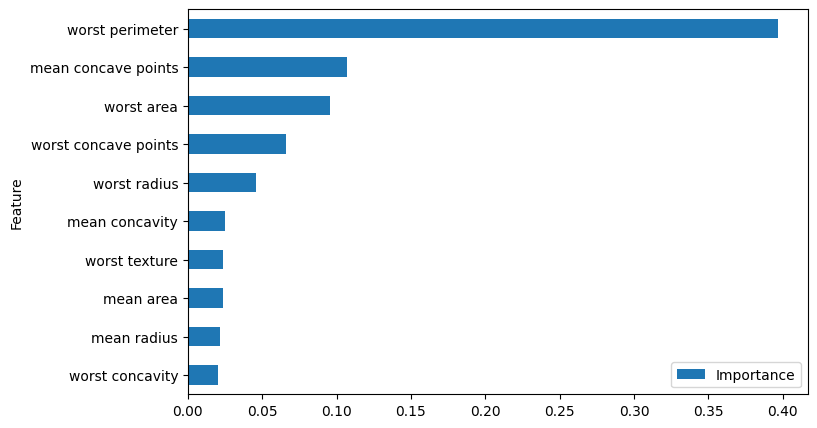

In [12]:
import matplotlib.pyplot as plt

feature_importance.head(10).sort_values(
    by='Importance'
    ).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8,5)
)
plt.show()

stacking

In [13]:
from sklearn.ensemble import  StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [14]:
base_learners=[
    ('lr',LogisticRegression(random_state=44)),
    ('svc',SVC(random_state=44))
]
meta_learner=DecisionTreeClassifier()

In [17]:
stack_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner
)

stack_clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

StackingClassifier(estimators=[('lr', LogisticRegression(random_state=44)),
                               ('svc', SVC(random_state=44))],
                   final_estimator=DecisionTreeClassifier())

In [18]:
y_pred_stacking=stack_clf.predict(X_test)
y_pred_stacking

array([0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 1])

In [19]:
accuracy_score(y_test,y_pred_stacking)

0.9473684210526315

In [20]:
confusion_matrix(y_test, y_pred_stacking)

array([[41,  1],
       [ 5, 67]])